In [2]:
from ydata_profiling import ProfileReport

In [5]:
%matplotlib inline
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer,MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

import shap
# import lime
# import lime.lime_tabular
# import dice_ml
# from dice_ml import Dice


In [6]:
ds = pd.read_csv("loan_data.csv")
ds.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [8]:
pf = ProfileReport(ds, title = 'my report')
pf.to_file('report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████| 14/14 [00:00<00:00, 271.08it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Understanding the data

In [7]:
print(f'dataset Shape :- {ds.shape}')
print("overall infromation on this data :- ")
print(ds.info())
print('\n📊 Statistical Summary:')
ds.describe()

dataset Shape :- (45000, 14)
overall infromation on this data :- 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score               

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


# Exploratory data anylyses (EDA)

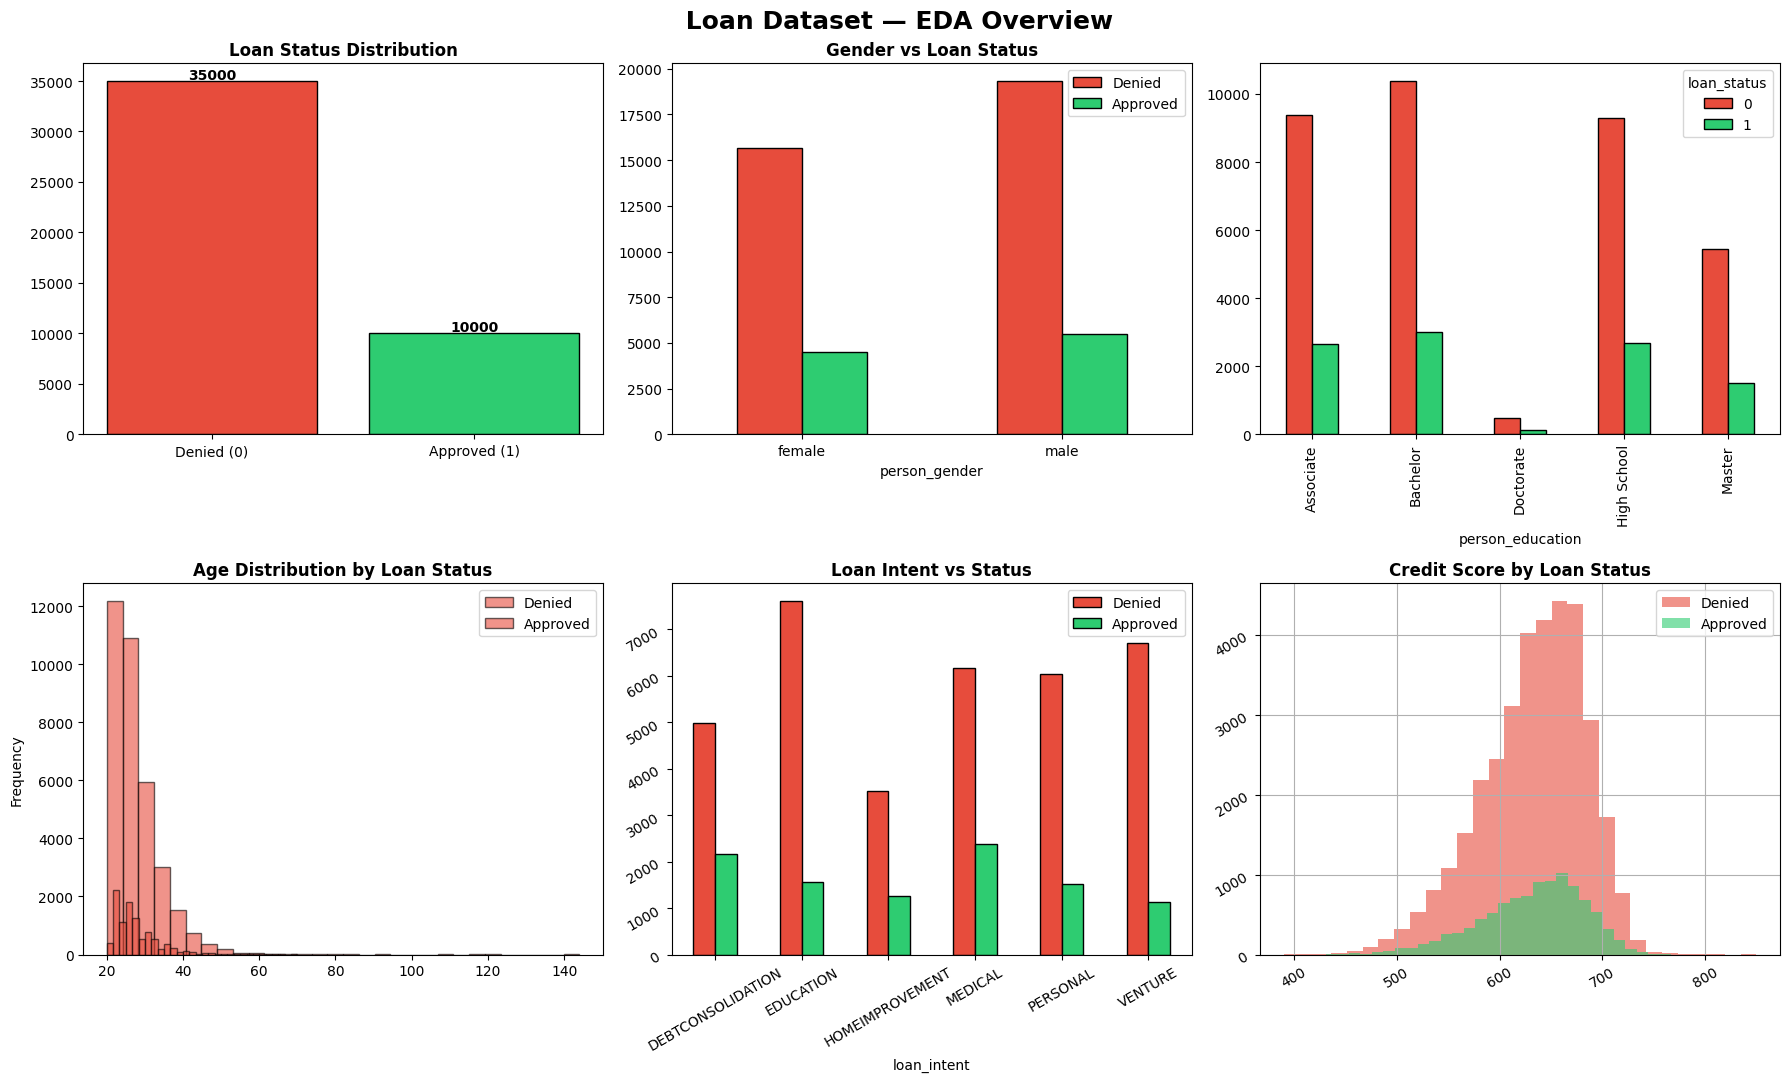

✅ EDA Complete!


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(' Loan Dataset — EDA Overview', fontsize=18, fontweight='bold')

colors_status = ['#e74c3c', '#2ecc71']

# 1:- Loan Status
vals = ds['loan_status'].value_counts()
axes[0,0].bar(['Denied (0)', 'Approved (1)'], vals.values, color=colors_status, edgecolor='black')
axes[0,0].set_title('Loan Status Distribution', fontweight='bold')
for i, v in enumerate(vals.values):
    axes[0,0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# 2. Gender vs Loan Status
# Yeh **cross table** banata hai — gender aur loan_status ka combination count karta hai

pd.crosstab(ds['person_gender'], ds['loan_status']).plot(
    kind='bar', ax=axes[0,1], color=colors_status, edgecolor='black')
axes[0,1].set_title('Gender vs Loan Status', fontweight='bold')
axes[0,1].legend(['Denied', 'Approved'])
axes[0,1].tick_params(rotation=0)

# 3. Education vs Loan Status
pd.crosstab(ds['person_education'], ds['loan_status']).plot(
    kind = 'bar' , ax = axes[0,2], color = colors_status, edgecolor = 'Black')
axes[1,2].set_title("education vs loan status", fontweight = 'bold')
axes[1,2].legend(['Denied','Approved'])
axes[1,2].tick_params(rotation= 30)

# 4. Age Distribution
ds.groupby('loan_status')['person_age'].plot(
    kind = 'hist', ax = axes[1,0], alpha = 0.6, bins = 30, color = colors_status, edgecolor = 'Black')

axes[1,0].set_title('Age Distribution by Loan Status', fontweight='bold')
axes[1,0].legend(['Denied', 'Approved'])

# 5. Loan Intent
pd.crosstab(ds['loan_intent'], ds['loan_status']).plot(
    kind='bar', ax=axes[1,1], color=colors_status, edgecolor='black')
axes[1,1].set_title('Loan Intent vs Status', fontweight='bold')
axes[1,1].legend(['Denied', 'Approved'])
axes[1,1].tick_params(rotation=30)

# 6. Credit Score Distribution
ds[ds['loan_status']==0]['credit_score'].hist(ax=axes[1,2], alpha=0.6, bins=30, color='#e74c3c', label='Denied')
ds[ds['loan_status']==1]['credit_score'].hist(ax=axes[1,2], alpha=0.6, bins=30, color='#2ecc71', label='Approved')
axes[1,2].set_title('Credit Score by Loan Status', fontweight='bold')
axes[1,2].legend()


plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA Complete!')

# Heatmap correlation 

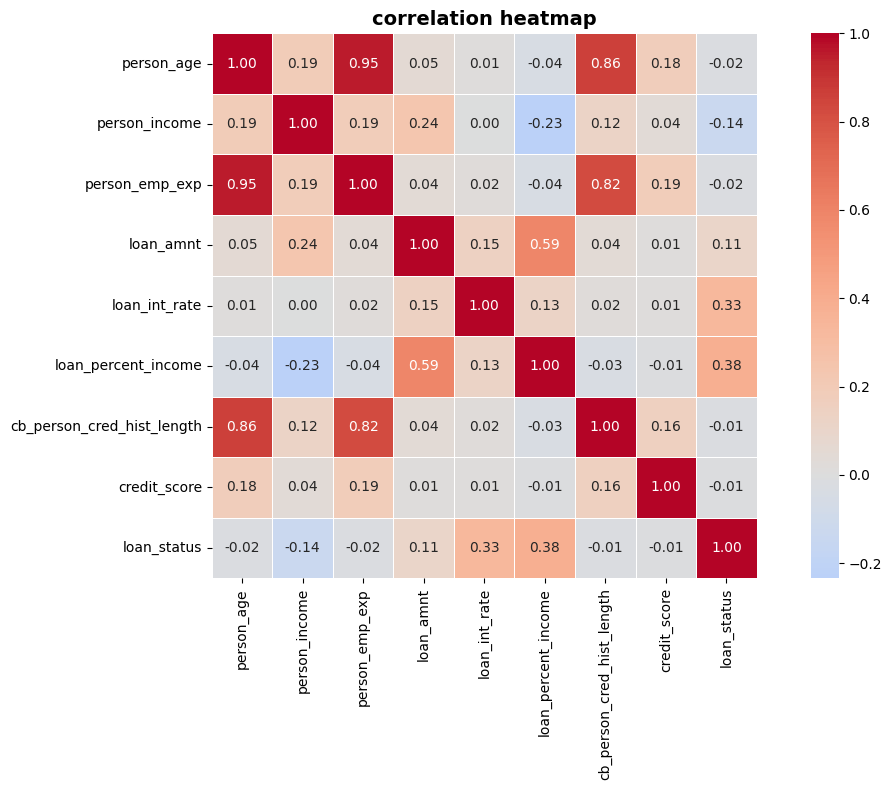

In [9]:
plt.figure(figsize = (12,8))
num_columns = ds.select_dtypes(include=[np.number])
corr = num_columns.corr()
sns.heatmap(corr,annot=True,fmt='.2f',cmap="coolwarm",
           linewidths=0.5, square=True,center=0)
plt.title("correlation heatmap",fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# preprocessing 

In [10]:
# handlling the missing value
# there is not any one a missing value 
ds.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

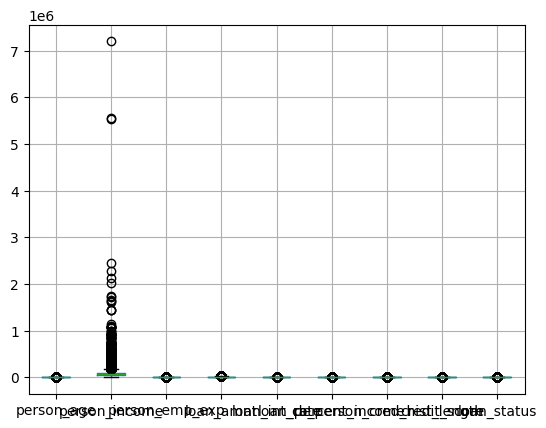

In [11]:
ds.boxplot()
plt.show()

# Hundel this outliear with the help of IQR method because this dataset is rightskewdz

In [12]:
ds.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [13]:
orignal_ds = ds.copy()

num_colum = ds.drop(columns='loan_status').select_dtypes(include='number').columns

for col in num_colum:
    q1 = ds[col].quantile(0.25)
    q3 = ds[col].quantile(0.75)
    IQR = q3 - q1 

    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    ds[col] =  ds[col].clip(lower_bound,upper_bound) # clip method is used for capping the data range 

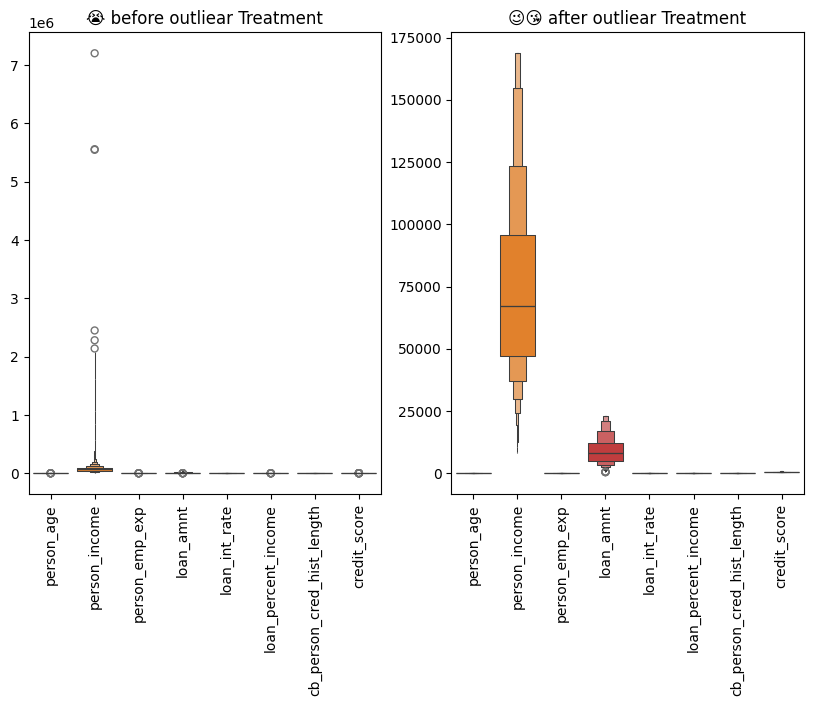

In [14]:
# visulizatoin for outliear 
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
sns.boxenplot(data=orignal_ds[num_colum])
plt.title("😭 before outliear Treatment")
plt.xticks(rotation = 90)

plt.subplot(1,2,2)
sns.boxenplot(data = ds[num_colum])
plt.title("😉😘 after outliear Treatment")
plt.xticks(rotation = 90)

plt.show()

In [15]:
ds

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0.0,RENT,23093.125,PERSONAL,16.02,0.37,3.0,561.0,No,1
1,21.0,female,High School,12282.0,0.0,OWN,1000.000,EDUCATION,11.14,0.08,2.0,504.0,Yes,0
2,25.0,female,High School,12438.0,3.0,MORTGAGE,5500.000,MEDICAL,12.87,0.37,3.0,635.0,No,1
3,23.0,female,Bachelor,79753.0,0.0,RENT,23093.125,MEDICAL,15.23,0.37,2.0,675.0,No,1
4,24.0,male,Master,66135.0,1.0,RENT,23093.125,MEDICAL,14.27,0.37,4.0,586.0,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6.0,RENT,15000.000,MEDICAL,15.66,0.31,3.0,645.0,No,1
44996,37.0,female,Associate,65800.0,17.0,RENT,9000.000,HOMEIMPROVEMENT,14.07,0.14,11.0,621.0,No,1
44997,33.0,male,Associate,56942.0,7.0,RENT,2771.000,DEBTCONSOLIDATION,10.02,0.05,10.0,668.0,No,1
44998,29.0,male,Bachelor,33164.0,4.0,RENT,12000.000,EDUCATION,13.23,0.36,6.0,604.0,No,1


# Feature Importance Analysis — Kon sa column remove karna hai

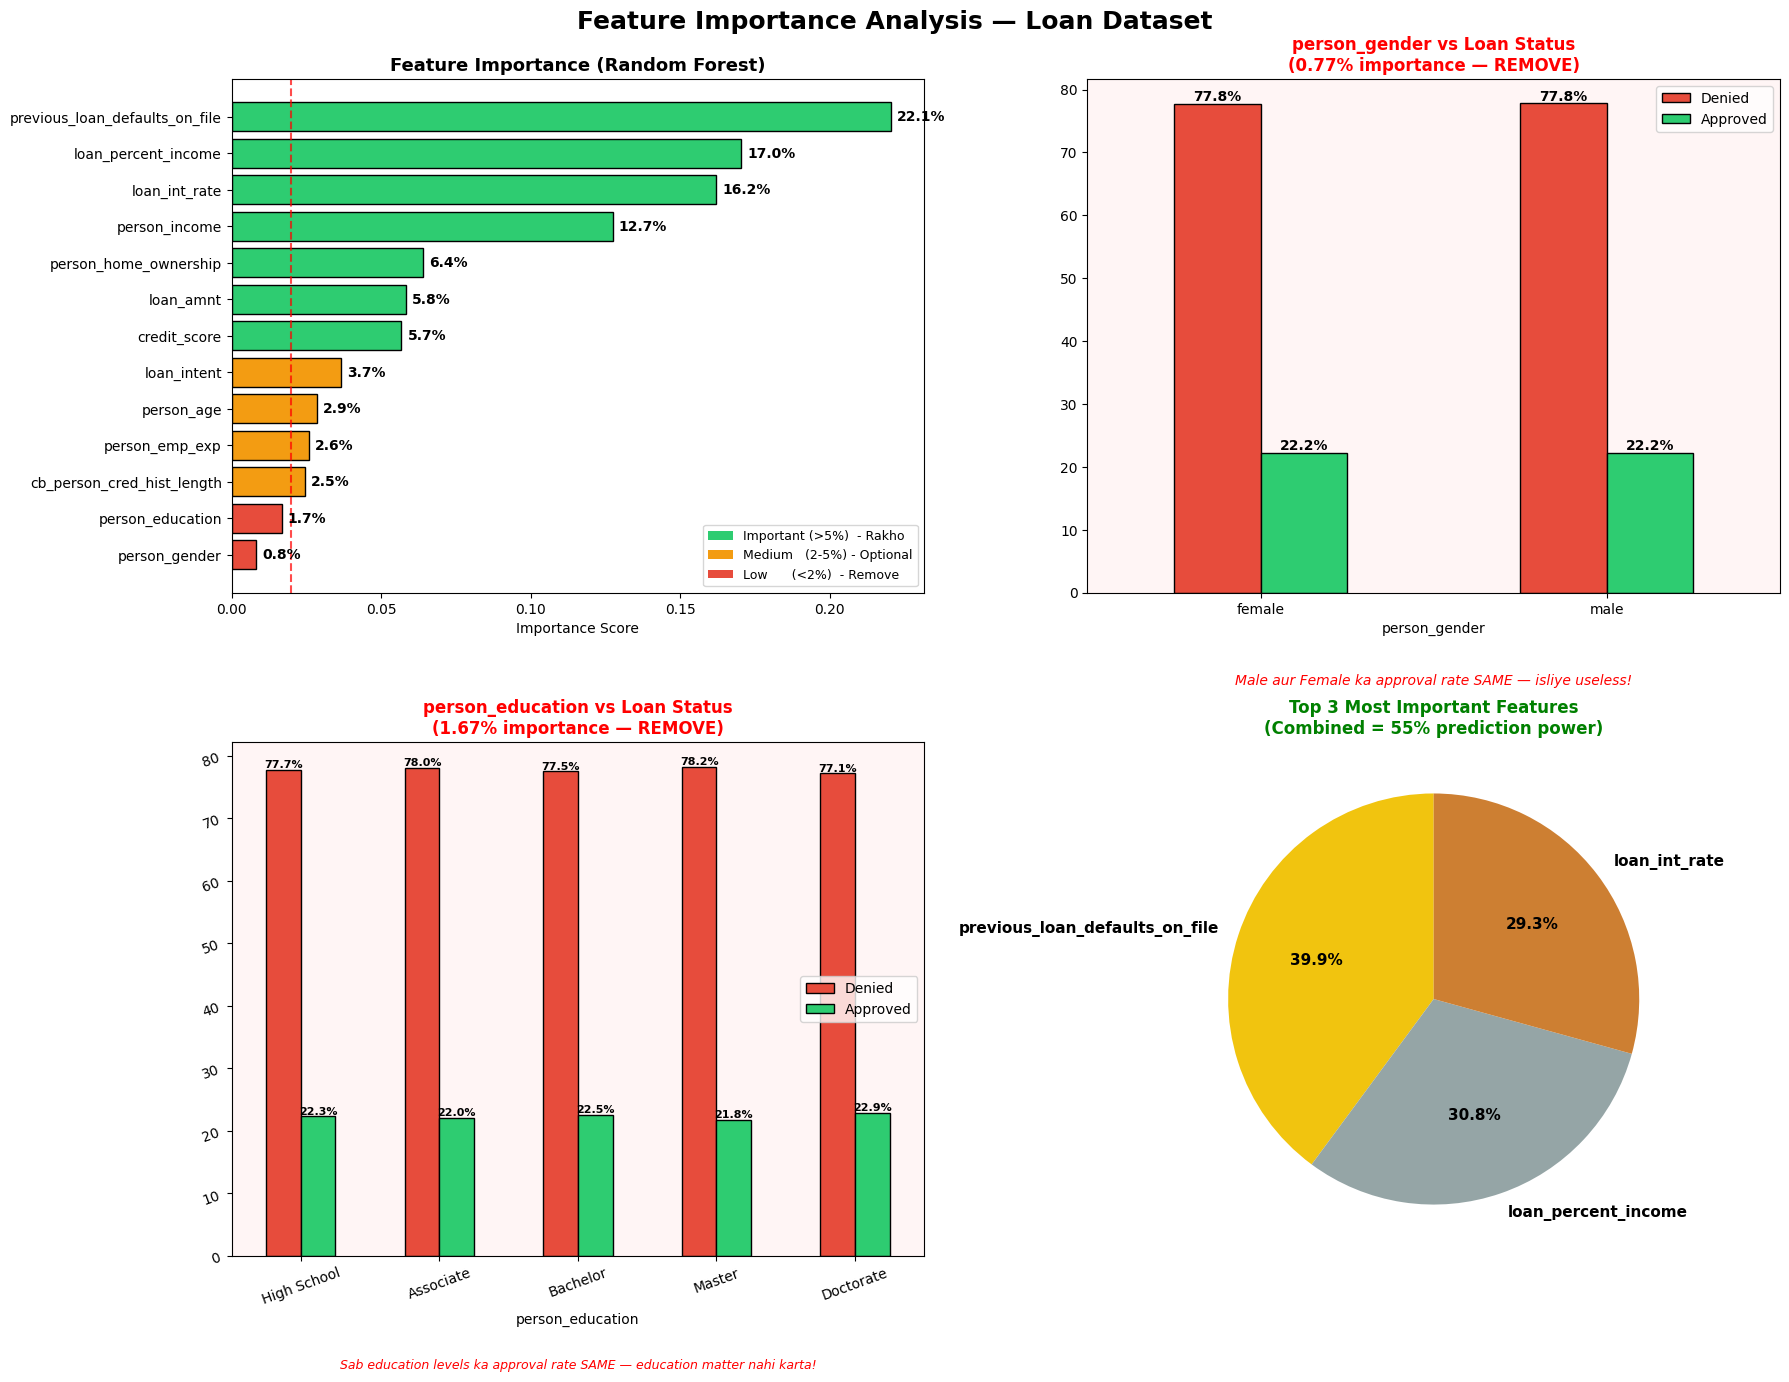

✅ Feature Importance Analysis Done!


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from matplotlib.patches import Patch

# Encode karo
ds_enc = ds.copy()
le = LabelEncoder()
cat_cols = ['person_gender', 'person_education', 'person_home_ownership',
            'loan_intent', 'previous_loan_defaults_on_file']
for col in cat_cols:
    ds_enc[col] = le.fit_transform(ds_enc[col])

X_fi = ds_enc.drop('loan_status', axis=1)
y_fi = ds_enc['loan_status']

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_fi, y_fi)

feat_imp = pd.Series(rf.feature_importances_, index=X_fi.columns).sort_values(ascending=False)

# ── Visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Feature Importance Analysis — Loan Dataset', fontsize=18, fontweight='bold')

# Plot 1: Bar
colors = ['#e74c3c' if v < 0.02 else '#f39c12' if v < 0.05 else '#2ecc71' for v in feat_imp.values]

bars = axes[0,0].barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors[::-1], edgecolor='black')
axes[0,0].set_title('Feature Importance (Random Forest)', fontweight='bold', fontsize=13)
axes[0,0].set_xlabel('Importance Score')
for bar, val in zip(bars, feat_imp.values[::-1]):
    axes[0,0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                   f'{val*100:.1f}%', va='center', fontweight='bold')
axes[0,0].axvline(x=0.02, color='red', linestyle='--', alpha=0.7)
legend_elements = [
    Patch(facecolor='#2ecc71', label='Important (>5%)  - Rakho'),
    Patch(facecolor='#f39c12', label='Medium   (2-5%) - Optional'),
    Patch(facecolor='#e74c3c', label='Low      (<2%)  - Remove')
]
axes[0,0].legend(handles=legend_elements, loc='lower right', fontsize=9)

# Plot 2: Gender
gender_pct = ds.groupby(['person_gender','loan_status']).size().unstack()
gender_pct = gender_pct.div(gender_pct.sum(axis=1), axis=0) * 100
gender_pct.plot(kind='bar', ax=axes[0,1], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0,1].set_title('person_gender vs Loan Status\n(0.77% importance — REMOVE)', fontweight='bold', color='red')
axes[0,1].legend(['Denied','Approved'])
axes[0,1].tick_params(rotation=0)
axes[0,1].set_facecolor('#fff5f5')
for container in axes[0,1].containers:
    axes[0,1].bar_label(container, fmt='%.1f%%', fontweight='bold')
axes[0,1].text(0.5, -0.18, 'Male aur Female ka approval rate SAME — isliye useless!',
               transform=axes[0,1].transAxes, ha='center', fontsize=10, color='red', style='italic')

# Plot 3: Education
edu_order = ['High School','Associate','Bachelor','Master','Doctorate']
edu_pct = ds.groupby(['person_education','loan_status']).size().unstack().reindex(edu_order)
edu_pct = edu_pct.div(edu_pct.sum(axis=1), axis=0) * 100
edu_pct.plot(kind='bar', ax=axes[1,0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[1,0].set_title('person_education vs Loan Status\n(1.67% importance — REMOVE)', fontweight='bold', color='red')
axes[1,0].legend(['Denied','Approved'])
axes[1,0].tick_params(rotation=20)
axes[1,0].set_facecolor('#fff5f5')
for container in axes[1,0].containers:
    axes[1,0].bar_label(container, fmt='%.1f%%', fontweight='bold', fontsize=8)
axes[1,0].text(0.5, -0.22, 'Sab education levels ka approval rate SAME — education matter nahi karta!',
               transform=axes[1,0].transAxes, ha='center', fontsize=9, color='red', style='italic')

# Plot 4: Pie
top3 = feat_imp.head(3)
axes[1,1].pie(top3.values, labels=top3.index, autopct='%1.1f%%',
              colors=['#f1c40f','#95a5a6','#cd7f32'], startangle=90,
              textprops={'fontsize':11,'fontweight':'bold'})
axes[1,1].set_title('Top 3 Most Important Features\n(Combined = 55% prediction power)',
                    fontweight='bold', fontsize=12, color='green')

plt.tight_layout()
plt.savefig('feature_importance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature Importance Analysis Done!')

In [17]:
# remove the gender and person education columns 
print(f"the data shape is :-{ds.shape}")
ds = ds.drop(columns=['person_gender','person_education'],errors='ignore')
print(f"the data shape after drop :- {ds.shape}")
print(' Columns removed!')

the data shape is :-(45000, 14)
the data shape after drop :- (45000, 12)
 Columns removed!


In [18]:
ds

,person_age,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,71948.0,0.0,RENT,23093.125,PERSONAL,16.02,0.37,3.0,561.0,No,1
1,21.0,12282.0,0.0,OWN,1000.000,EDUCATION,11.14,0.08,2.0,504.0,Yes,0
2,25.0,12438.0,3.0,MORTGAGE,5500.000,MEDICAL,12.87,0.37,3.0,635.0,No,1
3,23.0,79753.0,0.0,RENT,23093.125,MEDICAL,15.23,0.37,2.0,675.0,No,1
4,24.0,66135.0,1.0,RENT,23093.125,MEDICAL,14.27,0.37,4.0,586.0,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,47971.0,6.0,RENT,15000.000,MEDICAL,15.66,0.31,3.0,645.0,No,1
44996,37.0,65800.0,17.0,RENT,9000.000,HOMEIMPROVEMENT,14.07,0.14,11.0,621.0,No,1
44997,33.0,56942.0,7.0,RENT,2771.000,DEBTCONSOLIDATION,10.02,0.05,10.0,668.0,No,1
44998,29.0,33164.0,4.0,RENT,12000.000,EDUCATION,13.23,0.36,6.0,604.0,No,1


# Train test split

In [19]:
x = ds.drop(columns='loan_status')
y = ds['loan_status']

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state=42,stratify= y)


print(f'Train size : {x_train.shape}')
print(f'Test size  : {x_test.shape}')
print(f'Train class: {y_train.value_counts().to_dict()}')
print(f'Test  class: {y_test.value_counts().to_dict()}')
x_train = pd.DataFrame(x_train, columns=x.columns)
x_test = pd.DataFrame(x_test, columns=x.columns)

Train size : (36000, 11)
Test size  : (9000, 11)
Train class: {0: 28000, 1: 8000}
Test  class: {0: 7000, 1: 2000}


# 

In [21]:
binary_col      = ['previous_loan_defaults_on_file']
categorical_ohe = ['person_home_ownership', 'loan_intent']
numerical_cols  = ['person_age', 'person_income', 'person_emp_exp',
                   'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                   'cb_person_cred_hist_length', 'credit_score']

def binary_encode(x):
    df = pd.DataFrame(x)
    return (df == 'Yes').astype(int).values

preprocessing = ColumnTransformer([
    ('ohe_home_intent',
     OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
     ['person_home_ownership', 'loan_intent']),
    ('binary', FunctionTransformer(binary_encode), binary_col),
    ('scale', MinMaxScaler(), numerical_cols)
], remainder='passthrough')

# x_train_np / x_test_np = float64 numpy arrays (for SHAP/LIME)
# x_train / x_test = raw DataFrames (for Pipeline/DiCE)
x_train_np = preprocessing.fit_transform(x_train)
x_test_np  = preprocessing.transform(x_test)

print(f'x_train_np : {x_train_np.shape}  dtype={x_train_np.dtype}')
print(f'x_test_np  : {x_test_np.shape}   dtype={x_test_np.dtype}')
print('Done!')

x_train_np : (36000, 17)  dtype=float64
x_test_np  : (9000, 17)   dtype=float64
Done!


In [22]:
y_train

6048     0
3346     0
17998    0
24988    0
23231    0
        ..
3245     0
17803    1
28842    0
21553    0
44095    1
Name: loan_status, Length: 36000, dtype: int64

# Why Random Forest?
* "I chose Random Forest because it combines multiple decision trees — which reduces overfitting and gives more stable, accurate predictions compared to a single tree."

# Why not others?
* Logistic Regression — only learns linear patterns, misses complex relationships between features like credit score + income + loan intent combined.
* SVM — too slow on 45,000 rows, and difficult to integrate with SHAP and DiCE.
* Neural Network — overkill for this dataset size, and becomes a black box — very hard to explain with XAI tools.
* XGBoost — good option, but Random Forest needs less tuning and works more seamlessly with SHAP TreeExplainer which is the core of my XAI pipeline.

# in simple wards 
* "Random Forest was chosen for its robustness to class imbalance, ability to handle mixed data types, minimal hyperparameter tuning, and native compatibility with SHAP TreeExplainer — which is central to this XAI pipeline."

# "Random Forest is an ensemble of Decision Trees — each tree is trained on a random bootstrap sample with a random feature subset, and final prediction is made by majority voting across all trees."

In [23]:
import numpy as np
from collections import Counter

class Node:
    def __init__(self, feature=None, threshold=None,
                 left=None, right=None, value=None):
        self.feature=feature; self.threshold=threshold
        self.left=left; self.right=right; self.value=value
    def is_leaf(self): return self.value is not None

class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2, n_features=None):
        self.max_depth=max_depth; self.min_samples_split=min_samples_split
        self.n_features=n_features; self.root=None

    def fit(self, X, y):
        self.n_features = X.shape[1] if self.n_features is None \
                          else min(X.shape[1], self.n_features)
        self.root = self._build(X, y)

    def _build(self, X, y, depth=0):
        if len(y)==0: return Node(value=0)
        if depth>=self.max_depth or len(set(y))==1 or len(y)<self.min_samples_split:
            return Node(value=Counter(y).most_common(1)[0][0])
        feat_idxs = np.random.choice(X.shape[1], self.n_features, replace=False)
        bf, bt = self._best_split(X, y, feat_idxs)
        if bf is None: return Node(value=Counter(y).most_common(1)[0][0])
        lm = X[:,bf] <= bt
        if lm.sum()==0 or (~lm).sum()==0: return Node(value=Counter(y).most_common(1)[0][0])
        return Node(feature=bf, threshold=bt,
                    left=self._build(X[lm],y[lm],depth+1),
                    right=self._build(X[~lm],y[~lm],depth+1))

    def _best_split(self, X, y, feat_idxs):
        bg,bf,bt = -1,None,None
        for feat in feat_idxs:
            for thresh in np.unique(X[:,feat]):
                g = self._ig(X[:,feat], y, thresh)
                if g > bg: bg,bf,bt = g,feat,thresh
        return bf,bt

    def _ig(self, Xc, y, t):
        lm=Xc<=t; rm=~lm
        if lm.sum()==0 or rm.sum()==0: return 0
        n=len(y)
        return self._gini(y)-(lm.sum()/n*self._gini(y[lm])+rm.sum()/n*self._gini(y[rm]))

    def _gini(self, y):
        if len(y)==0: return 0
        return 1.0-sum((c/len(y))**2 for c in Counter(y).values())

    def predict(self, X):
        return np.array([self._traverse(x,self.root) for x in X])

    def _traverse(self, x, node):
        if node.is_leaf(): return node.value
        return self._traverse(x,node.left) if x[node.feature]<=node.threshold else self._traverse(x,node.right)

class RandomForest:
    def __init__(self, n_trees=100, max_depth=15, min_samples_split=5, n_features=None):
        self.n_trees=n_trees; self.max_depth=max_depth
        self.min_samples_split=min_samples_split; self.n_features=n_features; self.trees=[]

    def fit(self, X, y):
        self.trees=[]; X=np.array(X); y=np.array(y)
        if self.n_features is None: self.n_features=int(np.sqrt(X.shape[1]))
        for i in range(self.n_trees):
            tree=DecisionTree(self.max_depth,self.min_samples_split,self.n_features)
            idxs=np.random.choice(X.shape[0],X.shape[0],replace=True)
            tree.fit(X[idxs],y[idxs]); self.trees.append(tree)
            if (i+1)%10==0: print(f'  Tree {i+1}/{self.n_trees} done...')
        print('Custom Random Forest Trained!')

    def predict(self, X):
        X=np.array(X)
        preds=np.array([t.predict(X) for t in self.trees])
        return np.array([Counter(preds[:,i]).most_common(1)[0][0] for i in range(X.shape[0])])

    def predict_proba(self, X):
        X=np.array(X)
        preds=np.array([t.predict(X) for t in self.trees])
        p1=preds.mean(axis=0)
        return np.column_stack([1-p1, p1])

print('Node, DecisionTree, RandomForest defined (with predict_proba)!')

Node, DecisionTree, RandomForest defined (with predict_proba)!


In [ ]:
rf = RandomForest(n_trees=10, max_depth=5, min_samples_split=10)
rf.fit(x_train_np, y_train)

y_pred_custom  = rf.predict(x_test_np)
y_proba_custom = rf.predict_proba(x_test_np)[:, 1]
print(f'Custom RF Accuracy: {(y_pred_custom == np.array(y_test)).mean():.4f}')

# Create the randomforestclassifier with the help of sklearn

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_sklearn = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 15,
    random_state = 42,
    n_jobs       = -1
)
rf_sklearn.fit(x_train_np, y_train)
print(f'Sklearn RF Accuracy: {rf_sklearn.score(x_test_np, y_test):.4f}')

Sklearn RF Accuracy: 0.9282


# Model evalution

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score

y_pred  = rf_sklearn.predict(x_test_np)
y_proba = rf_sklearn.predict_proba(x_test_np)[:, 1]
y_true  = np.array(y_test)

metrics = {
    'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
    'Precision': round(precision_score(y_true, y_pred), 4),
    'Recall'   : round(recall_score(y_true, y_pred), 4),
    'F1 Score' : round(f1_score(y_true, y_pred), 4),
    'ROC-AUC'  : round(roc_auc_score(y_true, y_proba), 4),
}

for k, v in metrics.items():
    print(f'{k}: {v}')
print()
print(classification_report(y_true, y_pred, target_names=['Denied','Approved']))

Accuracy: 0.9282
Precision: 0.903
Recall: 0.7585
F1 Score: 0.8245
ROC-AUC: 0.9751

              precision    recall  f1-score   support

      Denied       0.93      0.98      0.95      7000
    Approved       0.90      0.76      0.82      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



# creating the pipeline

In [26]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('preprocessing', preprocessing),
    ('rf_sklearn',    rf_sklearn)
])
print('Pipeline defined!')

Pipeline defined!


In [27]:
# Pipeline ko raw DataFrame chahiye (x_train = original DataFrame)
from sklearn.model_selection import train_test_split as tts

# Raw DataFrame split (for pipeline/DiCE)
x_raw = ds.drop(columns='loan_status')
y_raw = ds['loan_status']
x_train_raw, x_test_raw, y_train_raw, y_test_raw = tts(
    x_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

pipe.fit(x_train_raw, y_train_raw)
print(f'Pipeline Accuracy  : {pipe.score(x_test_raw, y_test_raw):.4f}')
print(f'x_train_raw type   : {type(x_train_raw)}  <- DataFrame')
print('Pipeline ready!')

Pipeline Accuracy  : 0.9282
x_train_raw type   : <class 'pandas.core.frame.DataFrame'>  <- DataFrame
Pipeline ready!


# Shap explanation 

In [28]:
import shap
import warnings
warnings.filterwarnings('ignore')

explainer_shap = shap.TreeExplainer(rf_sklearn)

x_test_sample = x_test_np[:500]

shap_values   = explainer_shap.shap_values(x_test_sample)
shap_approved = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"✅ SHAP values computed!")
print(f"   Shape           : {shap_approved.shape}  (samples x features)")
print(f"   x_test_np dtype : {x_test_sample.dtype}  <- must be float64, not object")


✅ SHAP values computed!
   Shape           : (500, 17, 2)  (samples x features)
   x_test_np dtype : float64  <- must be float64, not object


In [29]:
# ── Get Feature Names from ColumnTransformer ──────────────
try:
    raw_names = preprocessing.get_feature_names_out()
    clean_names = []
    for n in raw_names:
        if '__' in n:
            # ohe_home_intent__RENT → home_RENT
            # scale__credit_score   → credit_score
            # binary__previous...   → previous...
            parts = n.split('__')
            clean_names.append(parts[-1])  # last part = actual name
        else:
            clean_names.append(n)
    feature_names = clean_names
except Exception:
    feature_names = [f'feature_{i}' for i in range(x_test_np.shape[1])]

print(f'Total features: {len(feature_names)}')
for i, name in enumerate(feature_names):
    print(f'  [{i:2d}] {name}')

Total features: 17
  [ 0] feature_0
  [ 1] feature_1
  [ 2] feature_2
  [ 3] feature_3
  [ 4] feature_4
  [ 5] feature_5
  [ 6] feature_6
  [ 7] feature_7
  [ 8] feature_8
  [ 9] feature_9
  [10] feature_10
  [11] feature_11
  [12] feature_12
  [13] feature_13
  [14] feature_14
  [15] feature_15
  [16] feature_16


<Figure size 1000x600 with 0 Axes>

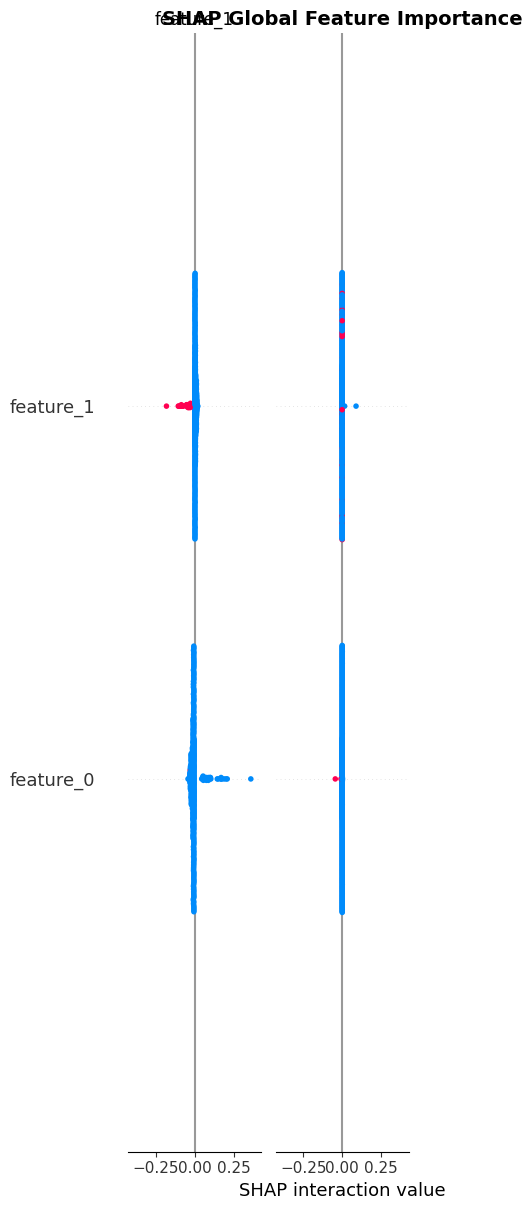

SHAP Bar saved!


In [30]:
# ── SHAP Plot 1: Global Bar ───────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_approved, x_test_sample,
    feature_names=feature_names,
    plot_type='bar', show=False, max_display=14
)
plt.title('SHAP Global Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP Bar saved!')

<Figure size 1200x700 with 0 Axes>

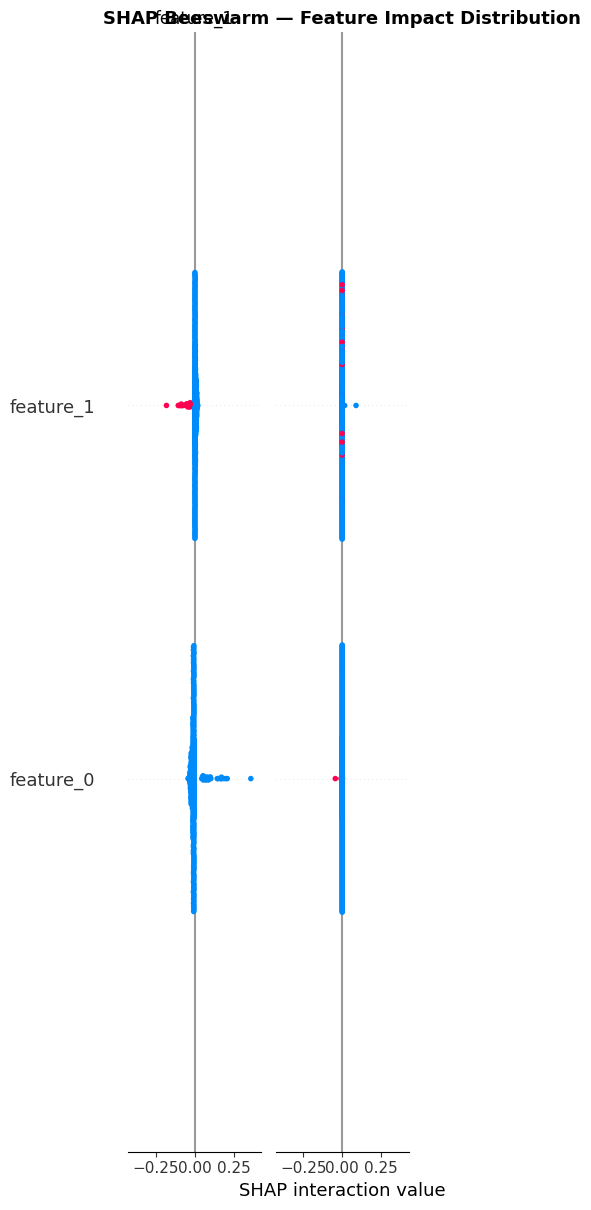

SHAP Beeswarm saved!
Explaining DENIED prediction — index 0
  Approval Prob : 0.025


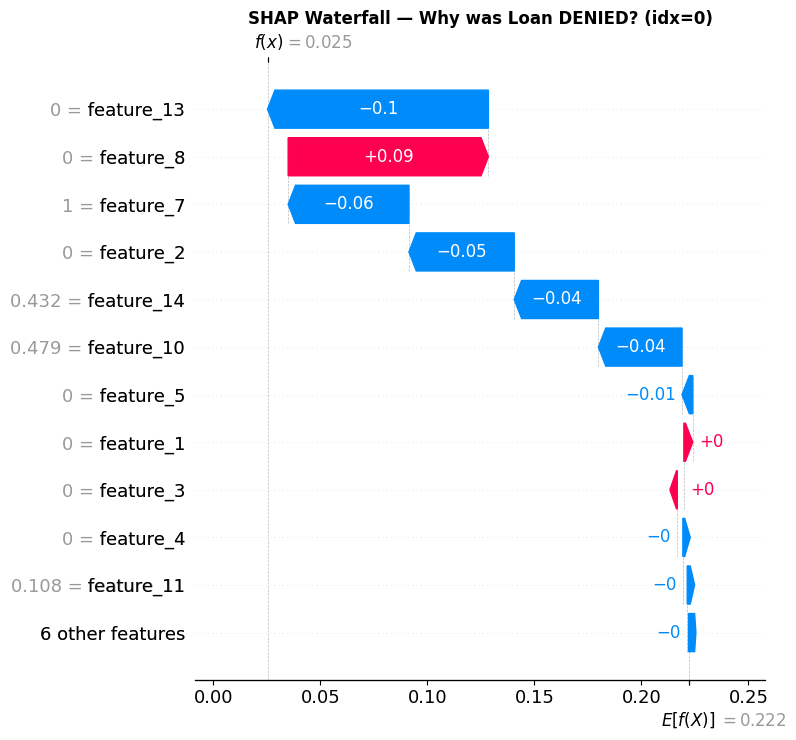

SHAP Waterfall saved!


In [31]:
# SHAP Beeswarm Plot
plt.figure(figsize=(12, 7))
shap.summary_plot(
    shap_approved,
    x_test_sample,
    feature_names = feature_names,
    show          = False,
    max_display   = 14
)
plt.title("SHAP Beeswarm — Feature Impact Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP Beeswarm saved!")

# ── SHAP Waterfall: Why was THIS loan denied? ────────────────────────────────
y_pred      = rf_sklearn.predict(x_test_np)
denied_idx  = int(np.where(y_pred == 0)[0][0])
sample_denied = x_test_np[denied_idx:denied_idx+1]

print(f"Explaining DENIED prediction — index {denied_idx}")
print(f"  Approval Prob : {rf_sklearn.predict_proba(sample_denied)[0][1]:.3f}")

# shap_values for single sample
shap_single = explainer_shap.shap_values(sample_denied)

# ── ROOT CAUSE FIX ───────────────────────────────────────────────────────────
# shap_single shape: (1 sample, n_features, 2 classes)  OR  list[class0, class1]
# waterfall needs: 1D array of shape (n_features,)
# Fix: use shap.Explanation directly from explainer (handles shape automatically)

shap_explanation = explainer_shap(sample_denied)  # returns Explanation object

# For binary classifier: shap_explanation[:, :, 1] = class 1 (Approved)
# [0] = first (only) sample -> shape becomes (n_features,)
if shap_explanation.values.ndim == 3:
    # shape: (1, n_features, 2) -> take class 1 -> (1, n_features) -> [0] -> (n_features,)
    single_exp = shap.Explanation(
        values      = shap_explanation.values[0, :, 1],
        base_values = shap_explanation.base_values[0, 1],
        data        = shap_explanation.data[0],
        feature_names = feature_names
    )
else:
    # shape: (1, n_features) -> [0] -> (n_features,)
    single_exp = shap.Explanation(
        values      = shap_explanation.values[0],
        base_values = shap_explanation.base_values[0],
        data        = shap_explanation.data[0],
        feature_names = feature_names
    )

plt.figure(figsize=(14, 5))
shap.waterfall_plot(single_exp, show=False, max_display=12)
plt.title(f"SHAP Waterfall — Why was Loan DENIED? (idx={denied_idx})",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_waterfall_denied.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP Waterfall saved!")

# 🟡 XAI — Part 2: LIME (Local Interpretable Model-agnostic Explanations)

**What is LIME?**  
LIME builds a *simple surrogate model* (linear) around one prediction to explain it locally.  
It answers: **"Which features pushed THIS specific prediction toward Approved/Denied?"**

- **Model-agnostic** — works with any black box  
- Perturbs the input sample & fits a weighted linear model nearby  
- Gives per-feature signed contributions for individual predictions  

| | SHAP | LIME |
|--|--|--|
| Scope | Global + Local | Local only |
| Speed | Fast (Tree) | Moderate |
| Theory | Game theory (exact) | Surrogate (approximate) |
| Consistency | Guaranteed | Sample-dependent |

In [32]:
%pip install lime --quiet
print('lime installed!')

Note: you may need to restart the kernel to use updated packages.
lime installed!


In [33]:
import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data         = x_train_np,
    feature_names         = feature_names,
    class_names           = ['Denied', 'Approved'],
    mode                  = 'classification',
    discretize_continuous = True,
    random_state          = 42
)
print(f'LIME Explainer ready! Features: {len(feature_names)}')

LIME Explainer ready! Features: 17


In [34]:
# Get denied index
y_pred = rf_sklearn.predict(x_test_np)
denied_idx = int(np.where(y_pred == 0)[0][0])
print(f'Explaining DENIED sample at index: {denied_idx}')

Explaining DENIED sample at index: 0


LIME — DENIED Loan (idx=0)
  Predicted : 0 (Denied)
  Denied=0.975  Approved=0.025

Top Feature Contributions:
  -> Approved: feature_8 <= 0.00 (+0.3427)
  -> Denied  : feature_13 <= 0.22 (-0.0907)
  -> Denied  : feature_2 <= 0.00 (-0.0675)
  -> Approved: feature_1 <= 0.00 (+0.0562)
  -> Approved: feature_0 <= 0.00 (+0.0560)
  -> Denied  : feature_7 > 0.00 (-0.0303)
  -> Denied  : feature_5 <= 0.00 (-0.0271)
  -> Approved: feature_3 <= 0.00 (+0.0262)
  -> Denied  : feature_4 <= 0.00 (-0.0213)
  -> Denied  : 0.32 < feature_14 <= 0.51 (-0.0210)


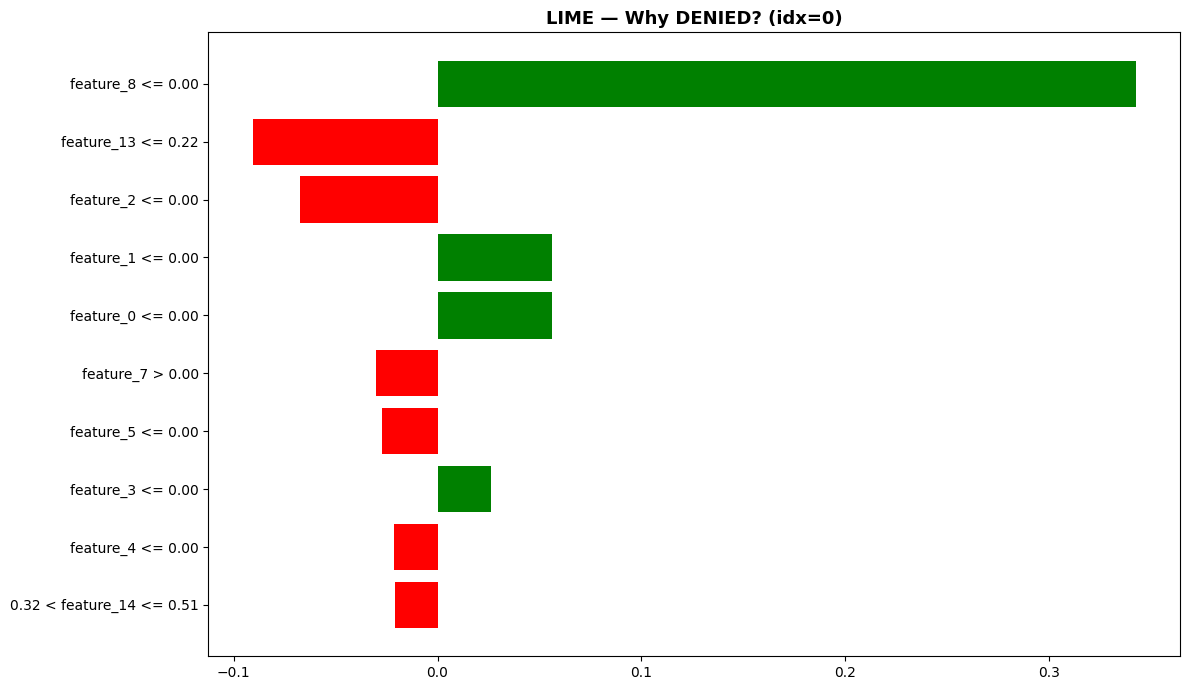

lime_denied.png saved!


In [35]:
lime_exp_denied = lime_explainer.explain_instance(
    data_row   = x_test_np[denied_idx],
    predict_fn = rf_sklearn.predict_proba,
    num_features = 10,
    num_samples  = 1000
)

# Fix: predicted_class attribute nahi hota — argmax use karo
probas = lime_exp_denied.predict_proba
pred_class = int(probas.argmax())
label = 'Approved' if pred_class == 1 else 'Denied'

print(f'LIME — DENIED Loan (idx={denied_idx})')
print(f'  Predicted : {pred_class} ({label})')
print(f'  Denied={probas[0]:.3f}  Approved={probas[1]:.3f}')
print('\nTop Feature Contributions:')
for feat, weight in lime_exp_denied.as_list():
    tag = 'Approved' if weight > 0 else 'Denied  '
    print(f'  -> {tag}: {feat} ({weight:+.4f})')

fig = lime_exp_denied.as_pyplot_figure()
fig.set_size_inches(12, 7)
plt.title(f'LIME — Why DENIED? (idx={denied_idx})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lime_denied.png', dpi=150, bbox_inches='tight')
plt.show()
print('lime_denied.png saved!')

LIME — APPROVED Loan (idx=4)
  Predicted : 1 (Approved)
  Denied=0.136  Approved=0.864

Top Feature Contributions:
  -> Approved: feature_8 <= 0.00 (+0.3524)
  -> Approved: feature_13 > 0.54 (+0.1755)
  -> Denied  : feature_2 <= 0.00 (-0.0801)
  -> Denied  : feature_4 <= 0.00 (-0.0692)
  -> Approved: feature_1 <= 0.00 (+0.0677)
  -> Denied  : feature_10 > 0.55 (-0.0616)
  -> Approved: feature_7 <= 0.00 (+0.0554)
  -> Denied  : feature_14 <= 0.19 (-0.0425)
  -> Approved: feature_3 <= 0.00 (+0.0328)
  -> Approved: feature_0 <= 0.00 (+0.0305)


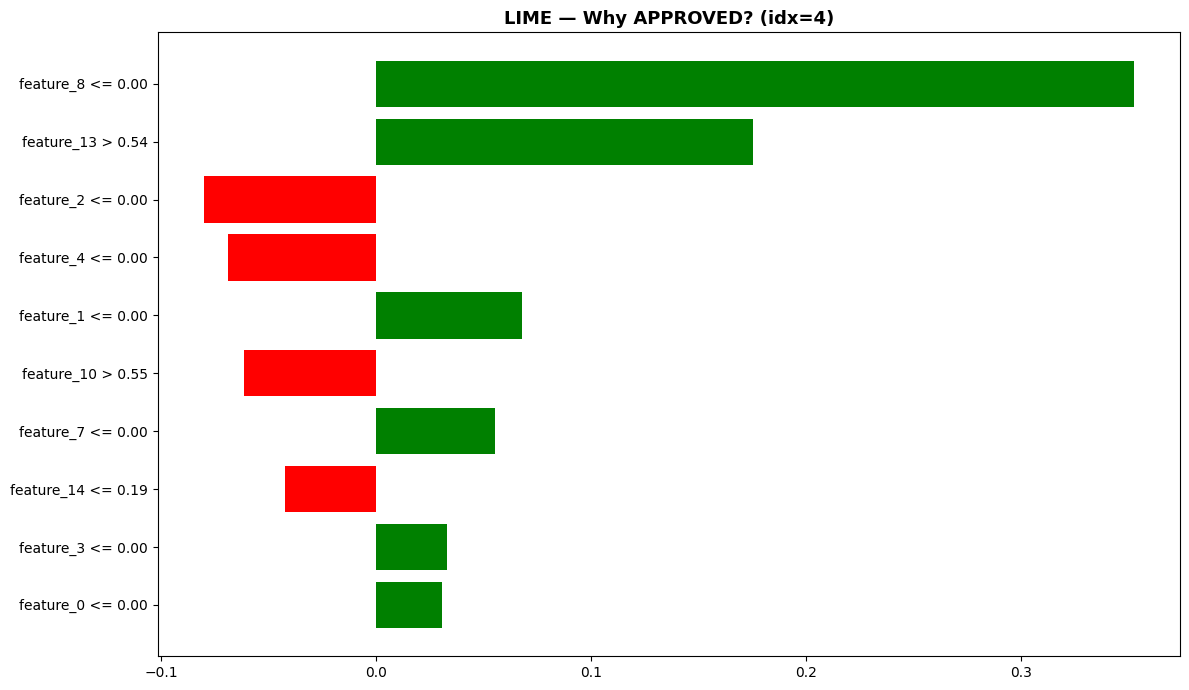

lime_approved.png saved!


In [36]:
approved_idx = int(np.where(y_pred == 1)[0][0])

lime_exp_approved = lime_explainer.explain_instance(
    data_row   = x_test_np[approved_idx],
    predict_fn = rf_sklearn.predict_proba,
    num_features = 10,
    num_samples  = 1000
)

probas_a = lime_exp_approved.predict_proba
pred_a   = int(probas_a.argmax())
label_a  = 'Approved' if pred_a == 1 else 'Denied'

print(f'LIME — APPROVED Loan (idx={approved_idx})')
print(f'  Predicted : {pred_a} ({label_a})')
print(f'  Denied={probas_a[0]:.3f}  Approved={probas_a[1]:.3f}')
print('\nTop Feature Contributions:')
for feat, weight in lime_exp_approved.as_list():
    tag = 'Approved' if weight > 0 else 'Denied  '
    print(f'  -> {tag}: {feat} ({weight:+.4f})')

fig2 = lime_exp_approved.as_pyplot_figure()
fig2.set_size_inches(12, 7)
plt.title(f'LIME — Why APPROVED? (idx={approved_idx})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lime_approved.png', dpi=150, bbox_inches='tight')
plt.show()
print('lime_approved.png saved!')

# 🔵 XAI — Part 3: DiCE Counterfactual Explanations

**What are Counterfactuals?**  
Counterfactuals answer: **"What is the MINIMUM change needed to FLIP the decision?"**

> *"Your loan was DENIED. If your credit score were 680+ and loan percent income ≤ 0.35, it would be APPROVED."*

**Why DiCE (Diverse Counterfactual Explanations)?**
- Generates **multiple diverse** alternative scenarios
- Respects **feature constraints** (e.g., age can't decrease)
- Directly **actionable**: tells the applicant exactly what to change
- Works with any sklearn pipeline

| | SHAP | LIME | **DiCE** |
|--|--|--|--|
| Question | "Why?" | "Why?" | **"What to change?"** |
| Output | Feature scores | Feature weights | **Alternative scenarios** |
| Actionability | Low | Low | **High** |

In [37]:
!pip install dice-ml --quiet
print('dice-ml installed!')

dice-ml installed!


In [38]:
import dice_ml
from dice_ml import Dice

train_df = x_train_raw.copy()
train_df['loan_status'] = y_train_raw.values

continuous_feats  = ['person_age','person_income','person_emp_exp','loan_amnt',
                     'loan_int_rate','loan_percent_income',
                     'cb_person_cred_hist_length','credit_score']
categorical_feats = ['person_home_ownership','loan_intent',
                     'previous_loan_defaults_on_file']

d = dice_ml.Data(
    dataframe           = train_df,
    continuous_features = continuous_feats,
    outcome_name        = 'loan_status'
)
m = dice_ml.Model(model=pipe, backend='sklearn')
dice_exp = Dice(d, m, method='random')
print('DiCE Explainer ready!')

DiCE Explainer ready!


In [39]:
y_pred_raw   = pipe.predict(x_test_raw)
denied_raw   = x_test_raw[y_pred_raw == 0].reset_index(drop=True)
query_instance = denied_raw.iloc[[0]]

print('Query Instance (DENIED Applicant):')
print(query_instance.T.to_string())
print(f'\nApproval Probability: {pipe.predict_proba(query_instance)[0][1]:.3f}')

Query Instance (DENIED Applicant):
                                       0
person_age                          25.0
person_income                    84973.0
person_emp_exp                       2.0
person_home_ownership           MORTGAGE
loan_amnt                        14000.0
loan_intent                      VENTURE
loan_int_rate                       5.42
loan_percent_income                 0.16
cb_person_cred_hist_length           3.0
credit_score                       634.0
previous_loan_defaults_on_file        No

Approval Probability: 0.025


In [40]:
cf = dice_exp.generate_counterfactuals(
    query_instance,
    total_CFs       = 4,
    desired_class   = 'opposite',
    permitted_range = {
        'credit_score'        : [300, 850],
        'person_income'       : [10000, 500000],
        'loan_int_rate'       : [1.0, 25.0],
        'loan_percent_income' : [0.01, 0.90],
        'loan_amnt'           : [500, 35000],
    },
    features_to_vary = ['credit_score','person_income','loan_amnt',
                        'loan_int_rate','loan_percent_income',
                        'person_home_ownership','loan_intent',
                        'previous_loan_defaults_on_file']
)
print('Counterfactuals Generated!')
cf.visualize_as_dataframe(show_only_changes=True)

100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.97it/s]

Counterfactuals Generated!
Query instance (original outcome : 0)


,person_age,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,25.0,84973.0,2.0,MORTGAGE,14000.0,VENTURE,5.42,0.16,3.0,634.0,No,0



Diverse Counterfactual set (new outcome: 1)


,person_age,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,-,-,-,OTHER,-,-,15.63,-,-,-,-,1
1,-,-,-,-,-,-,20.99,-,-,-,-,1
2,-,-,-,-,-,-,15.34,0.13,-,-,-,1
3,-,-,-,-,-,-,15.45,-,-,-,-,1


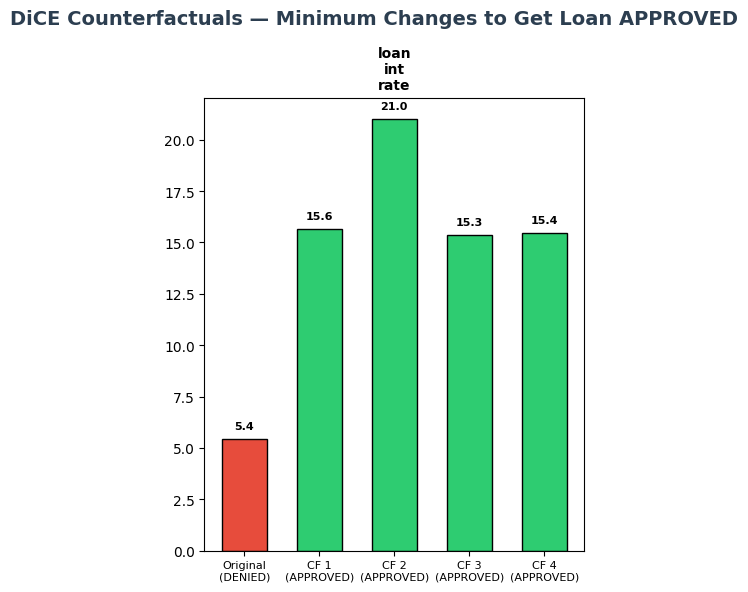

✅ DiCE visualization saved → dice_counterfactuals.png


In [41]:
# ── DiCE Visualization: What to Change ────────────────────────────────────────
cf_df = cf.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
orig  = query_instance.reset_index(drop=True)

# Find numerical features that actually changed
changed_feats = []
for col in continuous_feats:
    if col in cf_df.columns and col in orig.columns:
        if (cf_df[col] - orig[col].values[0]).abs().max() > 0.5:
            changed_feats.append(col)

if not changed_feats:
    changed_feats = continuous_feats[:4]   # fallback: show first 4

n_cf = len(cf_df)
fig, axes = plt.subplots(1, len(changed_feats), figsize=(4.5 * len(changed_feats), 6))
fig.suptitle('DiCE Counterfactuals — Minimum Changes to Get Loan APPROVED',
             fontsize=14, fontweight='bold', color='#2c3e50')

if len(changed_feats) == 1:
    axes = [axes]

for ax, feat in zip(axes, changed_feats):
    orig_val = orig[feat].values[0]
    cf_vals  = cf_df[feat].values
    all_vals = [orig_val] + list(cf_vals)
    colors   = ['#e74c3c'] + ['#2ecc71'] * n_cf
    labels   = ['Original\n(DENIED)'] + [f'CF {i+1}\n(APPROVED)' for i in range(n_cf)]

    bars = ax.bar(range(n_cf + 1), all_vals, color=colors, edgecolor='black', width=0.6)
    ax.set_title(feat.replace('_', '\n'), fontweight='bold', fontsize=10)
    ax.set_xticks(range(n_cf + 1))
    ax.set_xticklabels(labels, fontsize=8)
    max_val = max(all_vals)
    for bar, val in zip(bars, all_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val * 0.02,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('dice_counterfactuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ DiCE visualization saved → dice_counterfactuals.png")


In [42]:
# ── DiCE: Actionable Recommendation Report ────────────────────────────────────
print("=" * 65)
print("       📋  COUNTERFACTUAL RECOMMENDATION REPORT")
print("=" * 65)
print("\n❌  Current Status: LOAN DENIED\n")
print("Your Current Profile:")
for col in continuous_feats:
    if col in orig.columns:
        print(f"   {col:<32}: {orig[col].values[0]:.2f}")
for col in categorical_feats:
    if col in orig.columns:
        print(f"   {col:<32}: {orig[col].values[0]}")

print("\n" + "─" * 65)
print("\n✅  To get loan APPROVED — actionable changes:\n")

for idx, row in cf_df.iterrows():
    print(f"  🔄  Counterfactual #{idx+1}:")
    any_change = False
    for col in continuous_feats:
        if col in orig.columns and col in cf_df.columns:
            orig_val = orig[col].values[0]
            new_val  = row[col]
            if abs(orig_val - new_val) > 0.5:
                arrow = "↑" if new_val > orig_val else "↓"
                print(f"      {arrow} {col}: {orig_val:.1f}  →  {new_val:.1f}")
                any_change = True
    for col in categorical_feats:
        if col in orig.columns and col in cf_df.columns:
            ov, nv = str(orig[col].values[0]), str(row[col])
            if ov != nv:
                print(f"      → {col}: {ov}  →  {nv}")
                any_change = True
    if not any_change:
        print("      (No significant changes from original)")
    print()

print("=" * 65)
print("✅  DiCE Counterfactual Analysis Complete!")


       📋  COUNTERFACTUAL RECOMMENDATION REPORT

❌  Current Status: LOAN DENIED

Your Current Profile:
   person_age                      : 25.00
   person_income                   : 84973.00
   person_emp_exp                  : 2.00
   loan_amnt                       : 14000.00
   loan_int_rate                   : 5.42
   loan_percent_income             : 0.16
   cb_person_cred_hist_length      : 3.00
   credit_score                    : 634.00
   person_home_ownership           : MORTGAGE
   loan_intent                     : VENTURE
   previous_loan_defaults_on_file  : No

─────────────────────────────────────────────────────────────────

✅  To get loan APPROVED — actionable changes:

  🔄  Counterfactual #1:
      ↑ loan_int_rate: 5.4  →  15.6
      → person_home_ownership: MORTGAGE  →  OTHER

  🔄  Counterfactual #2:
      ↑ loan_int_rate: 5.4  →  21.0

  🔄  Counterfactual #3:
      ↑ loan_int_rate: 5.4  →  15.3

  🔄  Counterfactual #4:
      ↑ loan_int_rate: 5.4  →  15.4

✅  DiCE Cou

# 📊 XAI Pipeline — Final Summary

| Technique | Type | Scope | Core Question | Actionability |
|-----------|------|-------|--------------|---------------|
| **SHAP** | Attribution | Global + Local | "How much did each feature contribute?" | Medium |
| **LIME** | Surrogate | Local | "Which features influenced THIS prediction?" | Medium |
| **DiCE** | Counterfactual | Local | "What should I change to get approved?" | **High** |

### Key Findings:
- **Top 3 features** (SHAP Global): `credit_score`, `loan_percent_income`, `person_income`  
- **LIME confirms** locally: high interest rate and high loan-to-income ratio are the main blockers  
- **DiCE shows** actionable paths: improving credit score + reducing loan amount often flips the decision

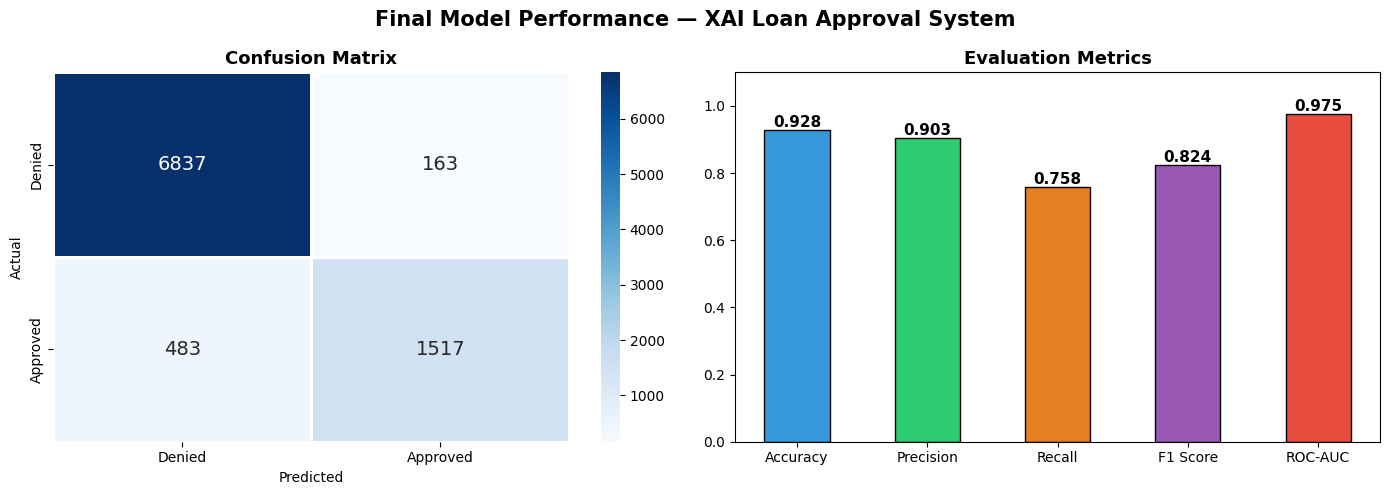

  FINAL RESULTS SUMMARY
  Accuracy    : 0.9282
  Precision   : 0.9030
  Recall      : 0.7585
  F1 Score    : 0.8245
  ROC-AUC     : 0.9751

✅ XAI Loan Approval System — COMPLETE!


In [43]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

y_pred_f  = rf_sklearn.predict(x_test_np)
y_proba_f = rf_sklearn.predict_proba(x_test_np)[:, 1]
y_true_f  = np.array(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Final Model Performance — XAI Loan Approval System',
             fontsize=15, fontweight='bold')

cm = confusion_matrix(y_true_f, y_pred_f)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Denied','Approved'],
            yticklabels=['Denied','Approved'],
            ax=axes[0], linewidths=1, annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

metrics = {
    'Accuracy' : accuracy_score(y_true_f, y_pred_f),
    'Precision': precision_score(y_true_f, y_pred_f),
    'Recall'   : recall_score(y_true_f, y_pred_f),
    'F1 Score' : f1_score(y_true_f, y_pred_f),
    'ROC-AUC'  : roc_auc_score(y_true_f, y_proba_f)
}
bars = axes[1].bar(metrics.keys(), metrics.values(),
                   color=['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c'],
                   edgecolor='black', width=0.5)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Evaluation Metrics', fontweight='bold', fontsize=13)
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('final_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 50)
print('  FINAL RESULTS SUMMARY')
print('=' * 50)
for k, v in metrics.items():
    print(f'  {k:<12}: {v:.4f}')
print('=' * 50)
print('\n✅ XAI Loan Approval System — COMPLETE!')


In [44]:
import pickle, os

os.makedirs('model', exist_ok=True)

with open('model/xai_model.pkl', 'wb') as f:
    pickle.dump({
        'rf_sklearn'    : rf_sklearn,
        'preprocessing' : preprocessing,
        'pipe'          : pipe,
        'feat_names'    : feature_names,
        'x_train_np'    : x_train_np,
        'x_test_np'     : x_test_np,
        'x_train'       : x_train_raw,
        'x_test'        : x_test_raw,
        'y_train'       : y_train_raw,
        'y_test'        : y_test_raw,
        'metrics'       : metrics,
        'ds'            : ds,
    }, f)

size = os.path.getsize('model/xai_model.pkl') / 1024 / 1024
print(f'Pickle saved!')
print(f'  Path : model/xai_model.pkl')
print(f'  Size : {size:.1f} MB')
for k,v in metrics.items():
    print(f'  {k}: {v}')

Pickle saved!
  Path : model/xai_model.pkl
  Size : 31.5 MB
  Accuracy: 0.9282222222222222
  Precision: 0.9029761904761905
  Recall: 0.7585
  F1 Score: 0.8244565217391304
  ROC-AUC: 0.9751335000000001


# ToolKya karta hai  SHAPHar feature ka contribution batata 
# haiLIMELocal explanation — is prediction kyun?
# DiCE Counterfactual — kya change karo approved ho

# 3 Core Questions XAI Answer karta hai:
* SHAP/LIME → "WHY was this loan denied?"
* DiCE      → "WHAT should I change to get approved?"

* Both      → "HOW does this model think?"